In [10]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Installation de dépendances**

In [12]:
!pip install -q datasets kaggle

# **Charger mangue + banane (Hugging Face, sans clé)**

In [13]:
from datasets import load_dataset

hf_dataset = load_dataset("darthraider/fruit-ripeness-detection-dataset")
print(hf_dataset)
print("Classes :", hf_dataset["train"].features["label"].names)

README.md:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  355MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 35.5MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 3999
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1000
    })
})
Classes : ['Raw_Banana', 'Raw_Mango', 'Ripe_Banana', 'Ripe_Mango']


In [14]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# **Télécharger le dataset ananas**

In [15]:
!kaggle datasets download -d adhilpk/pineapple -p /content/pineapple_raw --unzip
!find /content/pineapple_raw -type d

Dataset URL: https://www.kaggle.com/datasets/adhilpk/pineapple
License(s): GPL-2.0
100% 1.21G/1.21G [01:07<00:00, 19.3MB/s]

/content/pineapple_raw
/content/pineapple_raw/train
/content/pineapple_raw/train/obj
/content/pineapple_raw/test
/content/pineapple_raw/test/test


# **Construire la structure finale unifiée**

In [16]:
import os, shutil
from PIL import Image

base = "/content/data"
for fruit in ["mango", "banana", "pineapple"]:
    for stage in ["unripe", "ripe"]:
        os.makedirs(f"{base}/{fruit}/{stage}", exist_ok=True)

# Mangue + banane depuis Hugging Face
label_names = hf_dataset["train"].features["label"].names
for split in ["train", "test"]:
    for i, example in enumerate(hf_dataset[split]):
        label = label_names[example["label"]]
        fruit = "mango" if "Mango" in label else "banana"
        stage = "ripe" if "Ripe" in label else "unripe"
        example["image"].save(f"{base}/{fruit}/{stage}/{split}_{i}.jpg")

print("Mangue/banane organisées.")

Mangue/banane organisées.


# **Organiser l'ananas (à ADAPTER selon les noms vus à l'étape 4)**

In [17]:
import glob

# Remplace 'raw' et 'ripe' ci-dessous par les VRAIS noms de dossiers
# affichés par la cellule 4 (find /content/pineapple_raw)
pineapple_unripe_src = glob.glob("/content/pineapple_raw/**/raw*/*", recursive=True)
pineapple_ripe_src = glob.glob("/content/pineapple_raw/**/ripe*/*", recursive=True)

for f in pineapple_unripe_src:
    if os.path.isfile(f):
        shutil.copy(f, f"{base}/pineapple/unripe/")
for f in pineapple_ripe_src:
    if os.path.isfile(f):
        shutil.copy(f, f"{base}/pineapple/ripe/")

print(f"Ananas pas mûr : {len(os.listdir(base+'/pineapple/unripe'))} images")
print(f"Ananas mûr : {len(os.listdir(base+'/pineapple/ripe'))} images")

Ananas pas mûr : 0 images
Ananas mûr : 0 images


# **Vérification finale**

In [18]:
for fruit in ["mango", "banana", "pineapple"]:
    for stage in ["unripe", "ripe"]:
        n = len(os.listdir(f"{base}/{fruit}/{stage}"))
        print(f"{fruit} - {stage} : {n} images")

mango - unripe : 1250 images
mango - ripe : 1250 images
banana - unripe : 1249 images
banana - ripe : 1250 images
pineapple - unripe : 0 images
pineapple - ripe : 0 images


# **Inspection (à exécuter maintenant)**

In [19]:
import os

train_dir = "/content/pineapple_raw/train/obj"
files = os.listdir(train_dir)

print("Nombre total de fichiers :", len(files))
print("Exemples de fichiers :", files[:10])

# Chercher un fichier de classes (obj.names, classes.txt, etc.)
for f in os.listdir("/content/pineapple_raw/train"):
    print("Fichier dans train/ :", f)

# Extensions présentes
extensions = set(f.split('.')[-1] for f in files)
print("Extensions trouvées :", extensions)

Nombre total de fichiers : 2609
Exemples de fichiers : ['DSC_5867_edited.txt', 'DSC_5888_edited.jpg', 'edited (217).jpg', 'IMG_20200527_102154.txt', 'edited (123).txt', 'DSC_2312.txt', 'DSC_2240.txt', 'IMG_20200527_104124.jpg', 'IMG_20200527_105152.txt', 'DSC_5964_edited.jpg']
Fichier dans train/ : obj
Extensions trouvées : {'jpg', 'txt'}


# **Regarder le contenu d'un fichier d'annotation**

In [20]:
# Prend le premier fichier .txt trouvé et affiche son contenu
txt_files = [f for f in files if f.endswith('.txt')]
if txt_files:
    with open(os.path.join(train_dir, txt_files[0])) as f:
        print("Contenu de", txt_files[0], ":")
        print(f.read())
else:
    print("Aucun .txt trouvé directement dans obj/")

Contenu de DSC_5867_edited.txt :
1 0.485568 0.517591 0.817191 0.917632



# **Chercher le fichier de classes partout dans le dataset**

In [21]:
import subprocess

result = subprocess.run(
    ['find', '/content/pineapple_raw', '-iname', '*.names', '-o', '-iname', '*.data', '-o', '-iname', 'classes*'],
    capture_output=True, text=True
)
print(result.stdout)

# Lister aussi tout ce qui est à la racine et dans test/
print("--- Racine ---")
print(os.listdir("/content/pineapple_raw"))
print("--- test/ ---")
print(os.listdir("/content/pineapple_raw/test"))

/content/pineapple_raw/train/obj/classes.txt
/content/pineapple_raw/test/test/classes.txt

--- Racine ---
['train', 'test']
--- test/ ---
['test']


# **Vérifier la distribution des class_id dans les annotations**

In [22]:
txt_files_all = [f for f in os.listdir(train_dir) if f.endswith('.txt')]
class_ids = set()
for f in txt_files_all:
    with open(os.path.join(train_dir, f)) as file:
        line = file.readline().strip()
        if line:
            class_ids.add(line.split()[0])

print("Class IDs distincts trouvés :", class_ids)
print("Nombre de fichiers .txt :", len(txt_files_all))

Class IDs distincts trouvés : {'UNMATURED_PINEAPPLE', '0', '1'}
Nombre de fichiers .txt : 1305


In [23]:
with open("/content/pineapple_raw/train/obj/classes.txt") as f:
    classes = [line.strip() for line in f.readlines() if line.strip()]

print("Classes (dans l'ordre) :", classes)
for i, c in enumerate(classes):
    print(f"class_id {i} = {c}")

Classes (dans l'ordre) : ['UNMATURED_PINEAPPLE', 'MATURED_PINEAPPLE']
class_id 0 = UNMATURED_PINEAPPLE
class_id 1 = MATURED_PINEAPPLE


In [24]:
import shutil

class_map = {0: "unripe", 1: "ripe"}

for split_folder, split_name in [("train/obj", "train"), ("test/test", "test")]:
    folder = f"/content/pineapple_raw/{split_folder}"
    txt_files = [f for f in os.listdir(folder) if f.endswith('.txt') and f != 'classes.txt']

    for txt_file in txt_files:
        img_file = txt_file.replace('.txt', '.jpg')
        img_path = os.path.join(folder, img_file)
        txt_path = os.path.join(folder, txt_file)

        if not os.path.exists(img_path):
            continue

        with open(txt_path) as f:
            first_line = f.readline().strip()
            if not first_line:
                continue
            class_id = int(first_line.split()[0])

        stage = class_map.get(class_id)
        if stage:
            dest = f"{base}/pineapple/{stage}/{split_name}_{img_file}"
            shutil.copy(img_path, dest)

print(f"Ananas pas mûr : {len(os.listdir(base+'/pineapple/unripe'))} images")
print(f"Ananas mûr : {len(os.listdir(base+'/pineapple/ripe'))} images")

Ananas pas mûr : 509 images
Ananas mûr : 940 images


In [25]:
for fruit in ["mango", "banana", "pineapple"]:
    for stage in ["unripe", "ripe"]:
        n = len(os.listdir(f"{base}/{fruit}/{stage}"))
        print(f"{fruit} - {stage} : {n} images")

mango - unripe : 1250 images
mango - ripe : 1250 images
banana - unripe : 1249 images
banana - ripe : 1250 images
pineapple - unripe : 509 images
pineapple - ripe : 940 images


## **MODEL**

# **Construire la liste des fichiers et labels (classification à 6 classes)**

In [26]:
import numpy as np
from sklearn.model_selection import train_test_split

classes = ["mango_unripe", "mango_ripe", "banana_unripe", "banana_ripe",
           "pineapple_unripe", "pineapple_ripe"]

filepaths, labels = [], []
for fruit in ["mango", "banana", "pineapple"]:
    for stage in ["unripe", "ripe"]:
        folder = f"{base}/{fruit}/{stage}"
        class_name = f"{fruit}_{stage}"
        class_idx = classes.index(class_name)
        for fname in os.listdir(folder):
            filepaths.append(os.path.join(folder, fname))
            labels.append(class_idx)

filepaths = np.array(filepaths)
labels = np.array(labels)
print("Total images :", len(filepaths))

# Split 80% train / 10% val / 10% test, stratifié
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.2, stratify=labels, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Total images : 6448
Train: 5158 | Val: 645 | Test: 645


# **Pipeline de données (chargement, redimensionnement, augmentation)**

In [27]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
        ds = ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y))
        ds = ds.map(lambda x, y: (tf.image.random_brightness(x, 0.1), y))
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val)
test_ds = make_dataset(X_test, y_test)

# **Construire le modèle (transfer learning MobileNetV2)**

In [28]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # on gèle les poids pré-entraînés

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Entraînement (~10-15 min sur GPU T4)**

In [29]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 102s 420ms/step - accuracy: 0.9013 - loss: 0.2793 - val_accuracy: 0.9721 - val_loss: 0.0875
Epoch 2/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 233ms/step - accuracy: 0.9667 - loss: 0.0885 - val_accuracy: 0.9814 - val_loss: 0.0570
Epoch 3/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 233ms/step - accuracy: 0.9765 - loss: 0.0605 - val_accuracy: 0.9860 - val_loss: 0.0396
Epoch 4/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 46s 239ms/step - accuracy: 0.9804 - loss: 0.0541 - val_accuracy: 0.9860 - val_loss: 0.0431
Epoch 5/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 83s 239ms/step - accuracy: 0.9845 - loss: 0.0403 - val_accuracy: 0.9876 - val_loss: 0.0253
Epoch 6/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 45s 238ms/step - accuracy: 0.9880 - loss: 0.0339 - val_accuracy: 0.9814 - val_loss: 0.0433
Epoch 7/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 49s 265ms/step - accuracy: 0.9878 - loss: 0.0291 - val_accuracy: 0.9860 - val_loss: 0.0445
Epoch 8/15
162/162 ━━━━━━━━━━━━━━━━━━━━ 82s 269ms/step - accuracy: 0.9893 - loss: 

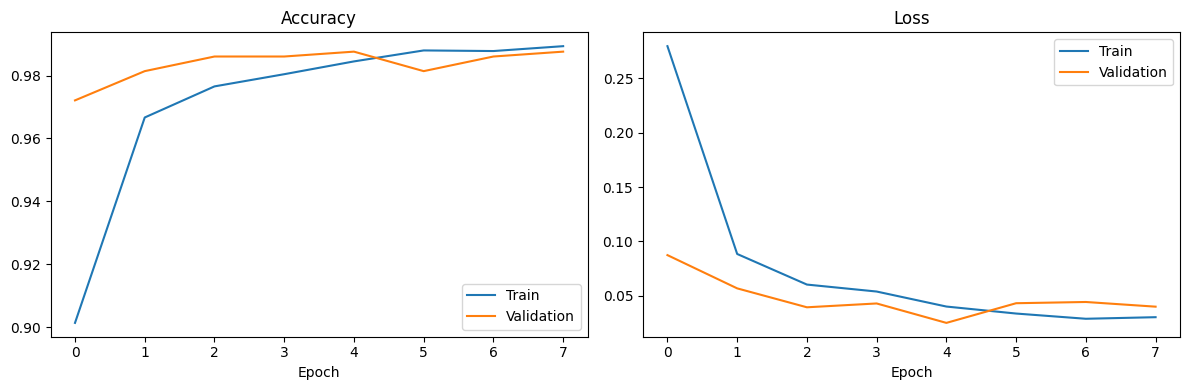

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.9814 - loss: 0.0548
Accuracy sur le test set : 0.981
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 464ms/step
                  precision    recall  f1-score   support

    mango_unripe       1.00      1.00      1.00       125
      mango_ripe       1.00      1.00      1.00       125
   banana_unripe       1.00      0.99      1.00       125
     banana_ripe       0.99      1.00      1.00       125
pineapple_unripe       0.92      0.86      0.89        51
  pineapple_ripe       0.93      0.96      0.94        94

        accuracy                           0.98       645
       macro avg       0.97      0.97      0.97       645
    weighted avg       0.98      0.98      0.98       645



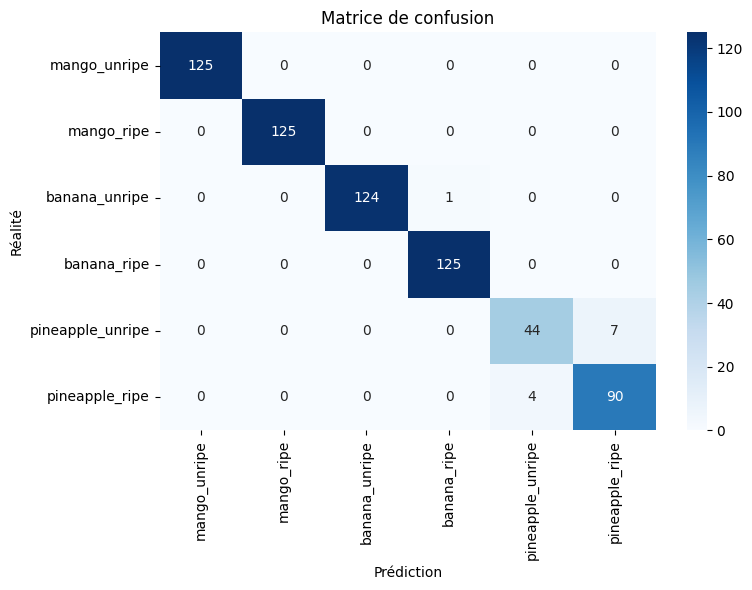

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds)
print(f"Accuracy sur le test set : {test_acc:.3f}")

y_pred = np.argmax(model.predict(test_ds), axis=1)
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de confusion')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

In [32]:
model.save('/content/fruit_ripeness_model.keras')
print("Modèle sauvegardé.")

Modèle sauvegardé.


In [33]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title="Maturité des Fruits Tropicaux", page_icon="🍌")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('fruit_ripeness_model.keras')

model = load_model()

classes = ["mango_unripe", "mango_ripe", "banana_unripe", "banana_ripe",
           "pineapple_unripe", "pineapple_ripe"]

labels_fr = {
    "mango_unripe": "Mangue — pas mûre",
    "mango_ripe": "Mangue — mûre",
    "banana_unripe": "Banane — pas mûre",
    "banana_ripe": "Banane — mûre",
    "pineapple_unripe": "Ananas — pas mûr",
    "pineapple_ripe": "Ananas — mûr",
}

st.title("🍌 Estimation de la Maturité des Fruits Tropicaux")
st.write("Uploadez une photo de mangue, banane ou ananas pour estimer son stade de maturité.")

uploaded_file = st.file_uploader("Choisir une image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Image chargée", use_container_width=True)

    img_resized = image.resize((224, 224))
    img_array = np.array(img_resized)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]
    predicted_idx = np.argmax(predictions)
    predicted_class = classes[predicted_idx]
    confidence = predictions[predicted_idx] * 100

    st.subheader(f"Résultat : {labels_fr[predicted_class]}")
    st.write(f"Confiance : {confidence:.1f}%")

    st.bar_chart({labels_fr[c]: float(p) for c, p in zip(classes, predictions)})

Overwriting app.py


In [34]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
changed 22 packages in 1s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [35]:
import subprocess, time

subprocess.Popen(['streamlit', 'run', 'app.py'],
                  stdout=open('/content/streamlit_logs.txt', 'w'),
                  stderr=subprocess.STDOUT)
time.sleep(3)

subprocess.Popen('npx localtunnel --port 8501 > /content/tunnel_logs.txt 2>&1', shell=True)
time.sleep(5)
print("Lancé en arrière-plan.")

Lancé en arrière-plan.


In [36]:
with open('/content/tunnel_logs.txt') as f:
    print(f.read())

your url is: https://all-hounds-write.loca.lt



In [38]:
!curl https://loca.lt/mytunnelpassword

35.240.165.130

In [8]:
with open('/content/streamlit_logs.txt') as f:
    print(f.read())



2026-08-16 16:53:45.178 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.165.130:8501




In [9]:
import os
print(os.path.exists('/content/fruit_ripeness_model.keras'))
print(os.getcwd())

False
/content


In [39]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [40]:
!pkill -f streamlit
!pkill -f localtunnel
!pkill -f cloudflared

import subprocess, time
subprocess.Popen(['streamlit', 'run', 'app.py',
                   '--server.headless', 'true'],
                  stdout=open('/content/streamlit_logs.txt', 'w'),
                  stderr=subprocess.STDOUT)
time.sleep(5)
print("Streamlit relancé.")

Streamlit relancé.


In [41]:
subprocess.Popen('./cloudflared tunnel --url http://localhost:8501 --logfile /content/cf_logs.txt',
                  shell=True)
time.sleep(8)

with open('/content/cf_logs.txt') as f:
    logs = f.read()

import re
match = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', logs)
if match:
    print("URL de ton app :", match.group())
else:
    print("Pas encore trouvée, attends 5s et relance cette cellule :")
    print(logs[-500:])

URL de ton app : https://least-valium-hired-documentation.trycloudflare.com


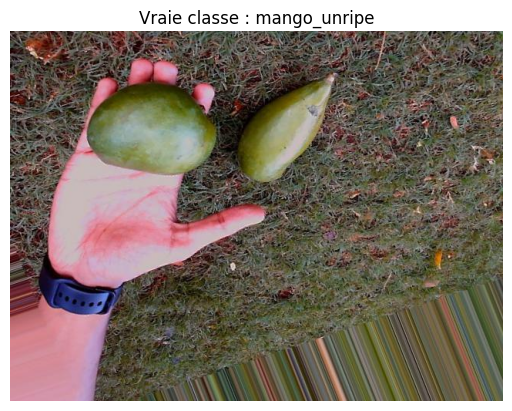

In [46]:
import matplotlib.pyplot as plt

idx = 7  # change l'index pour tester différentes images
img = Image.open(X_test[idx]).convert("RGB")
plt.imshow(img)
plt.title(f"Vraie classe : {classes[y_test[idx]]}")
plt.axis('off')
plt.show()

In [47]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/fruit-ripeness-cv', exist_ok=True)
shutil.copy('/content/fruit_ripeness_model.keras', '/content/drive/MyDrive/fruit-ripeness-cv/')
shutil.copy('/content/training_curves.png', '/content/drive/MyDrive/fruit-ripeness-cv/')
shutil.copy('/content/confusion_matrix.png', '/content/drive/MyDrive/fruit-ripeness-cv/')
print("Sauvegardé sur Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sauvegardé sur Drive.


In [50]:
##################################################
REPO = "landnjim/tropical-fruit-ripeness-cv"

!git clone https://{TOKEN}@github.com/{REPO}.git /content/repo



fatal: destination path '/content/repo' already exists and is not an empty directory.


In [51]:
import shutil, os

os.makedirs('/content/repo/app', exist_ok=True)
os.makedirs('/content/repo/report', exist_ok=True)
os.makedirs('/content/repo/notebooks', exist_ok=True)

shutil.copy('/content/fruit_ripeness_model.keras', '/content/repo/app/fruit_ripeness_model.keras')
shutil.copy('app.py', '/content/repo/app/app.py')
shutil.copy('/content/training_curves.png', '/content/repo/report/training_curves.png')
shutil.copy('/content/confusion_matrix.png', '/content/repo/report/confusion_matrix.png')

print("Fichiers copiés avec succès.")

FileExistsError: [Errno 17] File exists: '/content/repo/report'

In [52]:
import os

path = '/content/repo/report'
print("Existe :", os.path.exists(path))
print("Est un fichier :", os.path.isfile(path))
print("Est un dossier :", os.path.isdir(path))

Existe : True
Est un fichier : True
Est un dossier : False


In [53]:
import os, shutil

# Si c'est un fichier au lieu d'un dossier, on le supprime puis on recrée le dossier
if os.path.isfile('/content/repo/report'):
    os.remove('/content/repo/report')

os.makedirs('/content/repo/app', exist_ok=True)
os.makedirs('/content/repo/report', exist_ok=True)
os.makedirs('/content/repo/notebooks', exist_ok=True)

shutil.copy('/content/fruit_ripeness_model.keras', '/content/repo/app/fruit_ripeness_model.keras')
shutil.copy('app.py', '/content/repo/app/app.py')
shutil.copy('/content/training_curves.png', '/content/repo/report/training_curves.png')
shutil.copy('/content/confusion_matrix.png', '/content/repo/report/confusion_matrix.png')

print("Fichiers copiés avec succès.")
print(os.listdir('/content/repo/app'))
print(os.listdir('/content/repo/report'))

Fichiers copiés avec succès.
['app.py', '.gitkeep', 'fruit_ripeness_model.keras']
['training_curves.png', 'confusion_matrix.png']


In [55]:
%cd /content/repo
!git add .
!git config user.email "landersnjiminyi@gmail.com"
!git commit -m "Ajout modele, app Streamlit, courbes de resultats"
!git push

/content/repo
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [56]:
import os
print("app/ :", os.listdir('/content/repo/app'))
print("report/ :", os.listdir('/content/repo/report'))

app/ : ['app.py', '.gitkeep', 'fruit_ripeness_model.keras']
report/ : ['training_curves.png', 'confusion_matrix.png']


In [57]:
%cd /content/repo
!git status
!git log --oneline -5

/content/repo
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
9a98505 (HEAD -> main, origin/main, origin/HEAD) Ajout modele, app Streamlit, courbes de resultats
6e7453d Create report
3fbd112 Create .gitkeep
d4320ea Create .gitkeep
a1c4537 Create .gitkeep
